# 07. Komuter findings (Version 6, step 3)

What do the hours tell us that daily Rapid Rail data could not? This notebook uses the hourly Komuter trips to find the **home end** and the **work end** of commuting at each station, and checks the result against the Rapid Rail station types at the interchanges.

| Section | What it does |
|---|---|
| 0 | Settings |
| 1 | Load the clean trips and the stations; day types |
| 2 | Station activity: entries, exits, weekend ratio |
| 3 | The network by hour |
| 4 | Home score and station types |
| 5 | Interchanges: Komuter hours against Rapid Rail station types |
| 6 | Top destinations per station |
| 7 | Save the outputs |

**Period:** 1 June to 31 August 2026, the same as the main map. Public holidays in Kuala Lumpur count with weekends.

**Home score:** on working days, *morning entries + evening exits* (leaving home, coming back) against *morning exits + evening entries* (arriving at work, leaving work). A score near 1 is a home end, near 0 a work end.

**Keep in mind:** the KVDT2 track works close the Port Klang to KL Sentral line daily from 11:00 to 15:00 in 2026, so midday hours on that line are shaped by the timetable, not only by demand. The peaks, which the home score uses, are the most reliable part.

Needs `komuter_od_hourly.parquet` (07komuter1), `komuter_stations.csv` (07komuter2), and `station_population.csv` (04population1) in `data/processed`.

## 0. Settings

In [1]:
from pathlib import Path
import json
from datetime import datetime
import pandas as pd
import holidays
import matplotlib.pyplot as plt

START_DATE = "2026-06-01"          # <- same period as the main map
END_DATE   = "2026-08-31"

AM_PEAK = (6, 9)                   # <- morning peak, 06:00 to 09:59 (start hour, end hour)
PM_PEAK = (16, 19)                 # <- evening peak, 16:00 to 19:59
HOME_SPLIT = 0.6                   # <- home score at or above this = home-end
WORK_SPLIT = 0.4                   # <- home score at or below this = work-end
MIN_PEAK_TRIPS = 50                # <- stations with fewer peak trips a working day are not typed ("too few trips")
TOP_N = 5                          # <- destinations kept per station

PROCESSED = Path("data/processed")
OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)

# VISUAL: chart colours for the station types (notebook charts only; the page sets its own)
TYPE_COLOURS = {"Home-end": "#0C2363", "Mixed": "#9CA3AF", "Work-end": "#DC143C", "Too few trips": "#E5E7EB"}   # <-

## 1. Load the clean trips and the stations; day types

Only stations in the **Klang Valley** and the **outer belt** are analysed. Stations further away stay in the data as trip ends (for example a trip from Tapah Road to KL Sentral still counts at KL Sentral) but get no figures of their own. Temporary names (`same_as`, for example Segambut 2) are merged into the station they belong to.

In [2]:
od = pd.read_parquet(PROCESSED / "komuter_od_hourly.parquet")
stations = pd.read_csv(PROCESSED / "komuter_stations.csv")

same_as = stations.dropna(subset=["same_as"]).set_index("station")["same_as"].to_dict()
od["origin"] = od["origin"].replace(same_as)
od["destination"] = od["destination"].replace(same_as)
stations = stations[stations["same_as"].isna()].reset_index(drop=True)

start, end = pd.Timestamp(START_DATE), pd.Timestamp(END_DATE)
od = od[(od["date"] >= start) & (od["date"] <= end)].copy()

kl_holidays = holidays.Malaysia(years=[start.year, end.year], subdiv="KUL")
days = pd.DataFrame({"date": pd.date_range(start, end)})
days["is_holiday"] = days["date"].dt.date.map(lambda d: d in kl_holidays)
days["day_type"] = "working"
days.loc[(days["date"].dt.dayofweek >= 5) | days["is_holiday"], "day_type"] = "weekend_holiday"
n_days = days["day_type"].value_counts()
od = od.merge(days[["date", "day_type"]], on="date")

shown = stations[stations["region"].isin(["Klang Valley", "Outer belt"])]["station"].tolist()
print(f"Period {start.date()} to {end.date()}: {n_days.get('working', 0)} working days, "
      f"{n_days.get('weekend_holiday', 0)} weekend and holiday days")
print("Public holidays:", [f"{d.date()} {kl_holidays.get(d.date())}" for d in days.loc[days["is_holiday"], "date"]])
print(f"{len(od):,} rows, {od['ridership'].sum():,} trips; {len(shown)} stations analysed")

Period 2026-06-01 to 2026-08-31: 61 working days, 31 weekend and holiday days
Public holidays: ['2026-06-01 Hari Keputeraan Rasmi Seri Paduka Baginda Yang di-Pertuan Agong', '2026-06-02 Cuti Hari Wesak', '2026-06-17 Awal Muharam', '2026-08-25 Hari Keputeraan Nabi Muhammad S.A.W.', '2026-08-31 Hari Kebangsaan']
376,202 rows, 1,839,273 trips; 58 stations analysed


## 2. Station activity: entries, exits, weekend ratio

Average entries (trips starting at the station) and exits (trips ending there) per working day and per weekend or holiday day. The **weekend ratio** is defined as on the main map: weekend and holiday entries divided by working-day entries.

The data gives one hour per trip, most likely the hour the trip started; an exit is therefore counted in the hour the passenger boarded, usually less than an hour earlier than the actual exit.

In [3]:
def per_day(df, col):
    t = df.groupby([col, "day_type"])["ridership"].sum().unstack(fill_value=0)
    return t.div(n_days, axis=1).reindex(columns=["working", "weekend_holiday"], fill_value=0)

ent, ext = per_day(od, "origin"), per_day(od, "destination")
summary = pd.DataFrame({
    "entries_working": ent["working"], "entries_weekend": ent["weekend_holiday"],
    "exits_working": ext["working"], "exits_weekend": ext["weekend_holiday"],
}).reindex(shown).fillna(0)
summary["avg_daily_entries"] = (ent["working"] * n_days["working"] + ent["weekend_holiday"] * n_days["weekend_holiday"]).reindex(shown).fillna(0) / n_days.sum()
summary["weekend_ratio"] = summary["entries_weekend"] / summary["entries_working"].where(summary["entries_working"] > 0)

# Stations open for only part of the period (Segambut Utara opened in March 2026, so it is fully in) would need
# averaging over their days in service; check that every station has data on most days
active = od.groupby("origin")["date"].nunique().reindex(shown).fillna(0)
part = active[active < 0.9 * len(days)]
print("Stations with entries on fewer than 90% of days:", part.astype(int).to_dict() if len(part) else "none")

print(f"\nBusiest stations, average entries a day ({START_DATE} to {END_DATE}):")
print(summary.sort_values("avg_daily_entries", ascending=False)
      [["avg_daily_entries", "entries_working", "entries_weekend", "weekend_ratio"]].head(12).round(2).to_string())
print(f"\nNetwork weekend ratio: {summary['entries_weekend'].sum() / summary['entries_working'].sum():.2f} "
      f"(Rapid Rail on the main map: 0.61 at the median station)")

Stations with entries on fewer than 90% of days: none

Busiest stations, average entries a day (2026-06-01 to 2026-08-31):
                avg_daily_entries  entries_working  entries_weekend  weekend_ratio
KL Sentral                4440.40          5207.84          2930.29           0.56
Batu Caves                1385.74          1367.07          1422.48           1.04
Rawang                    1108.20          1265.85           797.97           0.63
Sungai Buloh              1009.39          1176.13           681.29           0.58
Tanjong Malim              731.89           698.84           796.94           1.14
Kuala Lumpur               655.15           756.15           456.42           0.60
Midvalley                  604.36           785.31           248.29           0.32
Bank Negara                563.43           708.95           277.10           0.39
Kajang                     559.77           744.67           195.94           0.26
Subang Jaya                485.64           649

## 3. The network by hour

Average entries per hour across all analysed stations, working days against weekends and holidays.

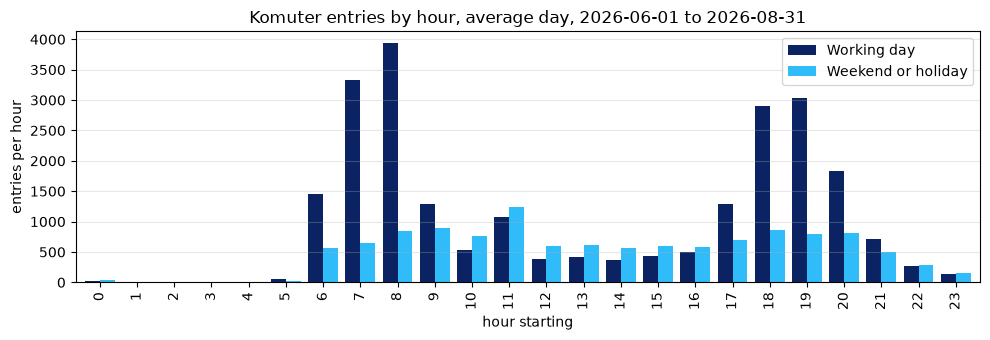

Working days: 42% of entries in the morning peak, 32% in the evening peak, 26% at other times. Busiest hour: 08:00 (16%).
Weekends and holidays: busiest hour 11:00 (10%).

Share of working-day entries from 11:00 to 14:59, by corridor (Port Klang Line closed then in 2026):
corridor
Port Klang Line     7.5%
Seremban Line      10.5%
Shared core        10.9%


In [4]:
in_area = od[od["origin"].isin(shown)]
net = in_area.groupby(["day_type", "hour"])["ridership"].sum().unstack(0).div(n_days, axis=1).reindex(range(24), fill_value=0)

# VISUAL: network entries by hour
fig, ax = plt.subplots(figsize=(10, 3.5))
net[["working", "weekend_holiday"]].plot(ax=ax, kind="bar", width=0.8, color=["#0C2363", "#30BCF8"])
ax.legend(["Working day", "Weekend or holiday"])
ax.set_title(f"Komuter entries by hour, average day, {START_DATE} to {END_DATE}")
ax.set_ylabel("entries per hour"); ax.set_xlabel("hour starting"); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

w = net["working"] / net["working"].sum() * 100
am = w.loc[AM_PEAK[0]:AM_PEAK[1]].sum(); pm = w.loc[PM_PEAK[0]:PM_PEAK[1]].sum()
print(f"Working days: {am:.0f}% of entries in the morning peak, {pm:.0f}% in the evening peak, "
      f"{100 - am - pm:.0f}% at other times. Busiest hour: {w.idxmax():02d}:00 ({w.max():.0f}%).")
wk = net["weekend_holiday"] / net["weekend_holiday"].sum() * 100
print(f"Weekends and holidays: busiest hour {wk.idxmax():02d}:00 ({wk.max():.0f}%).")

# The KVDT2 midday closure: share of working-day entries from 11:00 to 14:59, by corridor
corr = stations.set_index("station")["corridor"]
mid = in_area[in_area["day_type"] == "working"].assign(corridor=lambda d: d["origin"].map(corr))
mid_share = mid.groupby("corridor").apply(lambda d: d.loc[d["hour"].between(11, 14), "ridership"].sum() / d["ridership"].sum())
print("\nShare of working-day entries from 11:00 to 14:59, by corridor (Port Klang Line closed then in 2026):")
print(mid_share.map("{:.1%}".format).to_string())

## 4. Home score and station types

For each station, on working days:

- **home signal** = entries in the morning peak + exits in the evening peak
- **work signal** = exits in the morning peak + entries in the evening peak
- **home score** = home signal / (home signal + work signal)

The **morning share** (morning entries against morning plus evening entries) is shown alongside; it uses entries only and should tell the same story.

komuter_type
Home-end         42
Work-end         10
Mixed             4
Too few trips     2

Home score against morning share (rank correlation, typed stations): 0.99

Stations from most work-end to most home-end (peak trips a working day, both directions):
                         peak_trips  home_score  morning_share   komuter_type
Abdullah Hukum               1098.0        0.04           0.05       Work-end
Midvalley                    1447.0        0.06           0.06       Work-end
Bank Negara                  1090.0        0.09           0.11       Work-end
KL Sentral                   7072.0        0.12           0.14       Work-end
Subang Jaya                  1137.0        0.13           0.14       Work-end
Kuala Lumpur                  889.0        0.14           0.13       Work-end
Sungai Buloh                 1779.0        0.17           0.19       Work-end
Angkasapuri                    33.0        0.23           0.17  Too few trips
Kajang                       1268.0    

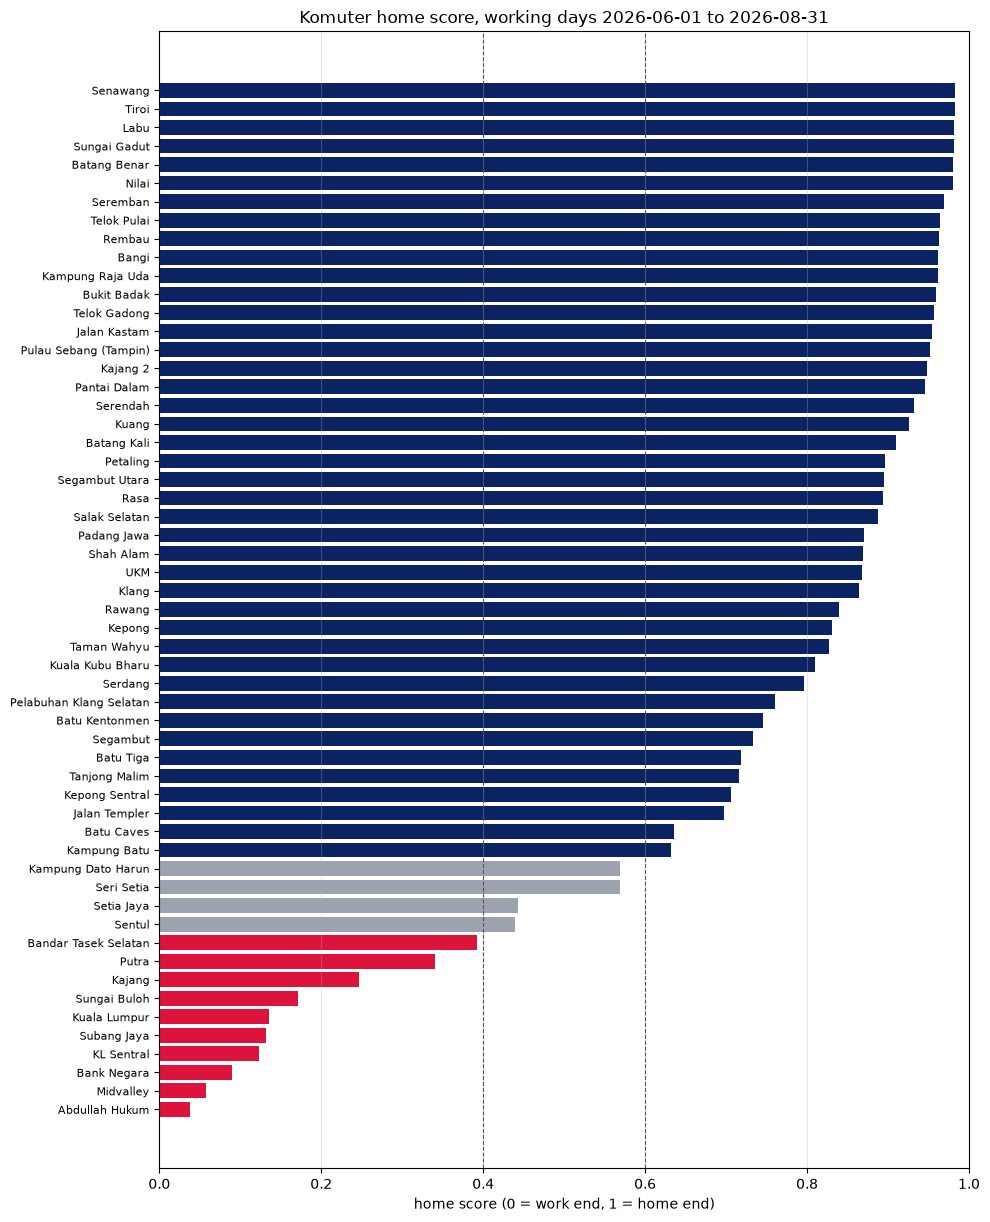

In [5]:
wd = od[od["day_type"] == "working"]
is_am = wd["hour"].between(*AM_PEAK); is_pm = wd["hour"].between(*PM_PEAK)
nw = n_days["working"]
am_in  = wd[is_am].groupby("origin")["ridership"].sum() / nw
pm_in  = wd[is_pm].groupby("origin")["ridership"].sum() / nw
am_out = wd[is_am].groupby("destination")["ridership"].sum() / nw
pm_out = wd[is_pm].groupby("destination")["ridership"].sum() / nw
peaks = pd.DataFrame({"am_in": am_in, "pm_in": pm_in, "am_out": am_out, "pm_out": pm_out}).reindex(shown).fillna(0)

peaks["home_signal"] = peaks["am_in"] + peaks["pm_out"]
peaks["work_signal"] = peaks["am_out"] + peaks["pm_in"]
peaks["peak_trips"] = peaks["home_signal"] + peaks["work_signal"]
peaks["home_score"] = peaks["home_signal"] / peaks["peak_trips"].where(peaks["peak_trips"] > 0)
peaks["morning_share"] = peaks["am_in"] / (peaks["am_in"] + peaks["pm_in"]).where(peaks["am_in"] + peaks["pm_in"] > 0)

def station_type(r):
    if r["peak_trips"] < MIN_PEAK_TRIPS or pd.isna(r["home_score"]):
        return "Too few trips"
    if r["home_score"] >= HOME_SPLIT:
        return "Home-end"
    if r["home_score"] <= WORK_SPLIT:
        return "Work-end"
    return "Mixed"

peaks["komuter_type"] = peaks.apply(station_type, axis=1)
summary = summary.join(peaks[["am_in", "pm_in", "am_out", "pm_out", "peak_trips", "home_score", "morning_share", "komuter_type"]])

print(summary["komuter_type"].value_counts().to_string())
typed = summary[summary["komuter_type"] != "Too few trips"]
agree = typed[["home_score", "morning_share"]].corr(method="spearman").iloc[0, 1]
print(f"\nHome score against morning share (rank correlation, typed stations): {agree:.2f}")

show = summary.sort_values("home_score")[["peak_trips", "home_score", "morning_share", "komuter_type"]]
print("\nStations from most work-end to most home-end (peak trips a working day, both directions):")
print(show.round({"peak_trips": 0, "home_score": 2, "morning_share": 2}).to_string())

# VISUAL: home score per station, coloured by type
s = summary[summary["komuter_type"] != "Too few trips"].sort_values("home_score")
fig, ax = plt.subplots(figsize=(10, max(4, 0.22 * len(s))))
ax.barh(s.index, s["home_score"], color=s["komuter_type"].map(TYPE_COLOURS))
ax.axvline(HOME_SPLIT, color="#555", lw=0.8, ls="--"); ax.axvline(WORK_SPLIT, color="#555", lw=0.8, ls="--")
ax.set_xlim(0, 1); ax.set_xlabel("home score (0 = work end, 1 = home end)")
ax.set_title(f"Komuter home score, working days {START_DATE} to {END_DATE}")
ax.tick_params(axis="y", labelsize=8); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

## 5. Interchanges: Komuter hours against Rapid Rail station types

At the interchanges found in `07komuter2`, the Komuter home score is set beside the Rapid Rail station type from `04population1` (which used entries per resident, a different method on different passengers). Agreement would support both methods; disagreement can be real, since the two networks serve different trips.

**Transfers look like work ends.** A passenger who rides Komuter in the morning and changes to the LRT or MRT at an interchange *exits* Komuter there in the morning, exactly like someone arriving at work. So a work-end score at an interchange may partly mean "transfer point", not "workplace". Rapid Rail tap-ins at the same station have the mirror problem.

In [6]:
rr_types = pd.read_csv(PROCESSED / "station_population.csv")[["key", "station_type", "entries_per_resident"]]
ic = stations[stations["interchange"] & stations["station"].isin(shown)][["station", "rr_station", "rr_key", "rr_distance_m"]]
ic = ic.merge(rr_types, left_on="rr_key", right_on="key", how="left").drop(columns="key")
ic = ic.join(summary[["home_score", "komuter_type", "peak_trips"]], on="station")

def agrees(r):
    if r["komuter_type"] in ("Too few trips", "Mixed") or pd.isna(r["station_type"]):
        return ""
    if r["komuter_type"] == "Home-end" and r["station_type"] in ("Home-end commuter", "Local neighbourhood"):
        return "yes"
    if r["komuter_type"] == "Work-end" and r["station_type"] in ("Work-end commuter", "Leisure destination"):
        return "yes"
    return "no"

ic["agrees"] = ic.apply(agrees, axis=1)
print(ic.sort_values("home_score")[["station", "rr_station", "home_score", "komuter_type", "station_type", "agrees"]]
        .round({"home_score": 2}).to_string(index=False))
n = (ic["agrees"] != "").sum()
print(f"\nAgree: {(ic['agrees'] == 'yes').sum()} of {n} comparable interchanges "
      "(home-end with home-end or local; work-end with work-end or leisure)")
strict = ((ic["komuter_type"] == "Home-end") & (ic["station_type"] == "Home-end commuter")) |          ((ic["komuter_type"] == "Work-end") & (ic["station_type"] == "Work-end commuter"))
print(f"Strict agreement (home-end with home-end commuter, work-end with work-end commuter only): {strict.sum()} of {n}")

             station           rr_station  home_score komuter_type        station_type agrees
      Abdullah Hukum       Abdullah Hukum        0.04     Work-end   Work-end commuter    yes
         Bank Negara            Bandaraya        0.09     Work-end   Work-end commuter    yes
          KL Sentral           KL Sentral        0.12     Work-end Leisure destination    yes
         Subang Jaya          Subang Jaya        0.13     Work-end   Work-end commuter    yes
        Kuala Lumpur           Pasar Seni        0.14     Work-end Leisure destination    yes
        Sungai Buloh         Sungai Buloh        0.17     Work-end Leisure destination    yes
              Kajang               Kajang        0.25     Work-end   Work-end commuter    yes
               Putra                 PWTC        0.34     Work-end Leisure destination    yes
Bandar Tasek Selatan Bandar Tasik Selatan        0.39     Work-end Leisure destination    yes
        Kampung Batu         Kampung Batu        0.63     Ho

## 6. Top destinations per station

For the click panel on the page: the `TOP_N` most common destinations from each station on working days, with trips a day. Trips to stations further away (for example Tapah Road) are included, since they are real journeys.

In [7]:
fl = (wd[wd["origin"].isin(shown) & (wd["origin"] != wd["destination"])]
        .groupby(["origin", "destination"])["ridership"].sum().div(nw).rename("trips_per_day").reset_index())
fl["rank"] = fl.groupby("origin")["trips_per_day"].rank(ascending=False, method="first")
flows_top = fl[fl["rank"] <= TOP_N].sort_values(["origin", "rank"]).reset_index(drop=True)
flows_top["trips_per_day"] = flows_top["trips_per_day"].round(1)
for s in ["KL Sentral", "Rawang", "Seremban"]:
    if s in flows_top["origin"].values:
        print(f"{s}:", ", ".join(f"{r.destination} ({r.trips_per_day:.0f})" for r in flows_top[flows_top["origin"] == s].itertuples()))

KL Sentral: Batu Caves (728), Rawang (451), Tanjong Malim (318), Seremban (226), Pantai Dalam (177)
Rawang: Sungai Buloh (474), KL Sentral (386), Bank Negara (86), Kuala Lumpur (59), Tanjong Malim (32)
Seremban: KL Sentral (212), Kajang (116), Midvalley (59), Bandar Tasek Selatan (51), Bank Negara (16)


## 7. Save the outputs

- `komuter_station_summary.csv`: one row per analysed station with coordinates, activity, peak counts, home score, morning share and type.
- `komuter_hourly.csv`: average entries and exits per station, day type and hour (for the hourly slider and the station charts).
- `komuter_flows_top.csv`: top destinations per station on working days.
- `komuter_metadata.json`: updated with the settings and headline results.

In [8]:
geo = stations.set_index("station")[["region", "district", "corridor", "lat", "lon", "interchange", "rr_station", "rr_key"]]
out = summary.join(geo).reset_index().rename(columns={"index": "station"})
out = out.round({c: 2 for c in ["entries_working", "entries_weekend", "exits_working", "exits_weekend", "avg_daily_entries",
                                "am_in", "pm_in", "am_out", "pm_out", "peak_trips"]} | {"weekend_ratio": 3, "home_score": 3, "morning_share": 3})
out.to_csv(PROCESSED / "komuter_station_summary.csv", index=False)

e = od[od["origin"].isin(shown)].groupby(["origin", "day_type", "hour"])["ridership"].sum().rename("entries")
x = od[od["destination"].isin(shown)].groupby(["destination", "day_type", "hour"])["ridership"].sum().rename("exits")
e.index.names = x.index.names = ["station", "day_type", "hour"]
hourly = pd.concat([e, x], axis=1).fillna(0).reset_index()
hourly[["entries", "exits"]] = hourly[["entries", "exits"]].div(hourly["day_type"].map(n_days), axis=0).round(2)
hourly.to_csv(PROCESSED / "komuter_hourly.csv", index=False)

flows_top.to_csv(PROCESSED / "komuter_flows_top.csv", index=False)

meta_path = PROCESSED / "komuter_metadata.json"
meta = json.loads(meta_path.read_text()) if meta_path.exists() else {}
meta.update({
    "findings_created": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "period_start": START_DATE, "period_end": END_DATE,
    "working_days": int(n_days.get("working", 0)), "weekend_holiday_days": int(n_days.get("weekend_holiday", 0)),
    "am_peak": f"{AM_PEAK[0]:02d}:00 to {AM_PEAK[1]:02d}:59", "pm_peak": f"{PM_PEAK[0]:02d}:00 to {PM_PEAK[1]:02d}:59",
    "home_score": "working days: (morning entries + evening exits) / (all four peak counts)",
    "home_split": HOME_SPLIT, "work_split": WORK_SPLIT, "min_peak_trips": MIN_PEAK_TRIPS,
    "type_counts": out["komuter_type"].value_counts().to_dict(),
    "interchange_agreement": f"{(ic['agrees'] == 'yes').sum()} of {(ic['agrees'] != '').sum()}",
})
meta_path.write_text(json.dumps(meta, indent=2))
for f in ["komuter_station_summary.csv", "komuter_hourly.csv", "komuter_flows_top.csv", "komuter_metadata.json"]:
    print(f"{f}: {(PROCESSED / f).stat().st_size / 1e3:.1f} kB")

komuter_station_summary.csv: 11.4 kB
komuter_hourly.csv: 96.4 kB
komuter_flows_top.csv: 9.5 kB
komuter_metadata.json: 1.5 kB


___
**END**